In [2]:

#Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All imports successful")

All imports successful


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tiku1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tiku1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\tiku1\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
#Load Data + Column Cleanup 
df_train = pd.read_csv("train.csv")
df_valid = pd.read_csv("valid.csv")
df_test  = pd.read_csv("test.csv")

cols_to_drop = ['id', 'date', 'state_info', 'speaker_description']
df_train.drop(columns=cols_to_drop, inplace=True)
df_valid.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True)

for df in [df_train, df_valid, df_test]:
    df['subject'] = df['subject'].where(df['subject'].notna(), other='unknown')
    df['context'] = df['context'].where(df['context'].notna(), other='unknown')

print("Remaining nulls in train:")
print(df_train.isnull().sum())
print("\nTrain shape:", df_train.shape)
print("Valid shape:", df_valid.shape)
print("Test shape:", df_test.shape)

Remaining nulls in train:
label                   0
statement               0
subject                 0
speaker                 0
true_counts             0
mostly_true_counts      0
half_true_counts        0
mostly_false_counts     0
false_counts            0
pants_on_fire_counts    0
context                 0
justification           0
dtype: int64

Train shape: (18369, 12)
Valid shape: (2297, 12)
Test shape: (2296, 12)


In [4]:

#Label Preparation (Binary Only)

# {0,1,2} = Fake (0), {3,4,5} = Real (1)
def to_binary(label):
    return 0 if label in [0, 1, 2] else 1

y_train = df_train['label'].apply(to_binary).values
y_valid = df_valid['label'].apply(to_binary).values
y_test  = df_test['label'].apply(to_binary).values

print("Binary distribution (train):")
print(pd.Series(y_train).value_counts())
print("\nBinary distribution (valid):")
print(pd.Series(y_valid).value_counts())
print("\nBinary distribution (test):")
print(pd.Series(y_test).value_counts())

Binary distribution (train):
0    10591
1     7778
Name: count, dtype: int64

Binary distribution (valid):
0    1325
1     972
Name: count, dtype: int64

Binary distribution (test):
0    1323
1     973
Name: count, dtype: int64


In [5]:

# Speaker Credibility Ratios + RobustScaler

credit_cols = ['true_counts', 'mostly_true_counts', 'half_true_counts',
               'mostly_false_counts', 'false_counts', 'pants_on_fire_counts']

# Step 4a — Compute total counts per speaker (no zeros confirmed earlier)
for df in [df_train, df_valid, df_test]:
    df['total_counts'] = df[credit_cols].sum(axis=1)

# Step 4b — Convert raw counts to ratios (removes effect of fame/exposure)
ratio_cols = []
for col in credit_cols:
    ratio_col = col.replace('_counts', '_ratio')
    for df in [df_train, df_valid, df_test]:
        df[ratio_col] = df[col] / df['total_counts']
    ratio_cols.append(ratio_col)

# Step 4c — Apply RobustScaler on ratios
# Fit ONLY on train, transform valid and test (golden rule of ML)
scaler = RobustScaler()
X_train_meta = scaler.fit_transform(df_train[ratio_cols])
X_valid_meta  = scaler.transform(df_valid[ratio_cols])
X_test_meta   = scaler.transform(df_test[ratio_cols])

print("Credibility feature matrix shape (train):", X_train_meta.shape)
print("\nSample ratios for first speaker:")
print(df_train[ratio_cols].iloc[0].round(3))
print("\nRatios sum to 1.0 check:")
print(df_train[ratio_cols].iloc[0].sum().round(3))

Credibility feature matrix shape (train): (18369, 6)

Sample ratios for first speaker:
true_ratio             0.05
mostly_true_ratio      0.20
half_true_ratio        0.25
mostly_false_ratio     0.15
false_ratio            0.25
pants_on_fire_ratio    0.10
Name: 0, dtype: float64

Ratios sum to 1.0 check:
1.0


In [6]:

#Text Cleaning Function
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Step 1 — lowercase
    text = text.lower()
    # Step 2 — remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Step 3 — remove punctuation and digits
    text = re.sub(r'[^a-z\s]', '', text)
    # Step 4 — tokenize
    tokens = text.split()
    # Step 5 — remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

# Quick sanity check on one statement
sample = df_train['statement'].iloc[0]
print("Original:", sample)
print("Cleaned :", clean_text(sample))

Original: 90 percent of Americans "support universal background checks" for gun purchases.
Cleaned : percent american support universal background check gun purchase


In [7]:

#Apply Text Cleaning
print("Cleaning statements...")
for df in [df_train, df_valid, df_test]:
    df['clean_statement']     = df['statement'].apply(clean_text)
    df['clean_justification'] = df['justification'].apply(clean_text)

# Combine statement + justification into one rich text field
for df in [df_train, df_valid, df_test]:
    df['combined_text'] = df['clean_statement'] + ' ' + df['clean_justification']

print("Done.")
print("\nSample combined text:")
print(df_train['combined_text'].iloc[0])

Cleaning statements...
Done.

Sample combined text:
percent american support universal background check gun purchase universal term background check done every gun sale found support policy percent latest national poll support ranged percent percent four recent poll expert say support near percent consistent year statement accurate nothing significant missing rating


In [8]:

#TF-IDF Vectorization

# Fit ONLY on train — transform valid and test
tfidf = TfidfVectorizer(
    max_features=50000,   # top 50k terms
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,             # ignore terms appearing in only 1 document
    sublinear_tf=True     # apply log normalization to term frequency
)

X_train_tfidf = tfidf.fit_transform(df_train['combined_text'])
X_valid_tfidf = tfidf.transform(df_valid['combined_text'])
X_test_tfidf  = tfidf.transform(df_test['combined_text'])

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (valid):", X_valid_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

TF-IDF matrix shape (train): (18369, 50000)
TF-IDF matrix shape (valid): (2297, 50000)
TF-IDF matrix shape (test): (2296, 50000)


In [9]:

# Final Feature Matrix Assembly
# Combine TF-IDF text features + speaker credibility ratios
# hstack joins them side by side into one matrix

X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta)])
X_valid_final = hstack([X_valid_tfidf, csr_matrix(X_valid_meta)])
X_test_final  = hstack([X_test_tfidf,  csr_matrix(X_test_meta)])

print("Final feature matrix shape (train):", X_train_final.shape)
print("Final feature matrix shape (valid):", X_valid_final.shape)
print("Final feature matrix shape (test):", X_test_final.shape)

print("\nPreprocessing complete. Ready for modelling.")

Final feature matrix shape (train): (18369, 50006)
Final feature matrix shape (valid): (2297, 50006)
Final feature matrix shape (test): (2296, 50006)

Preprocessing complete. Ready for modelling.


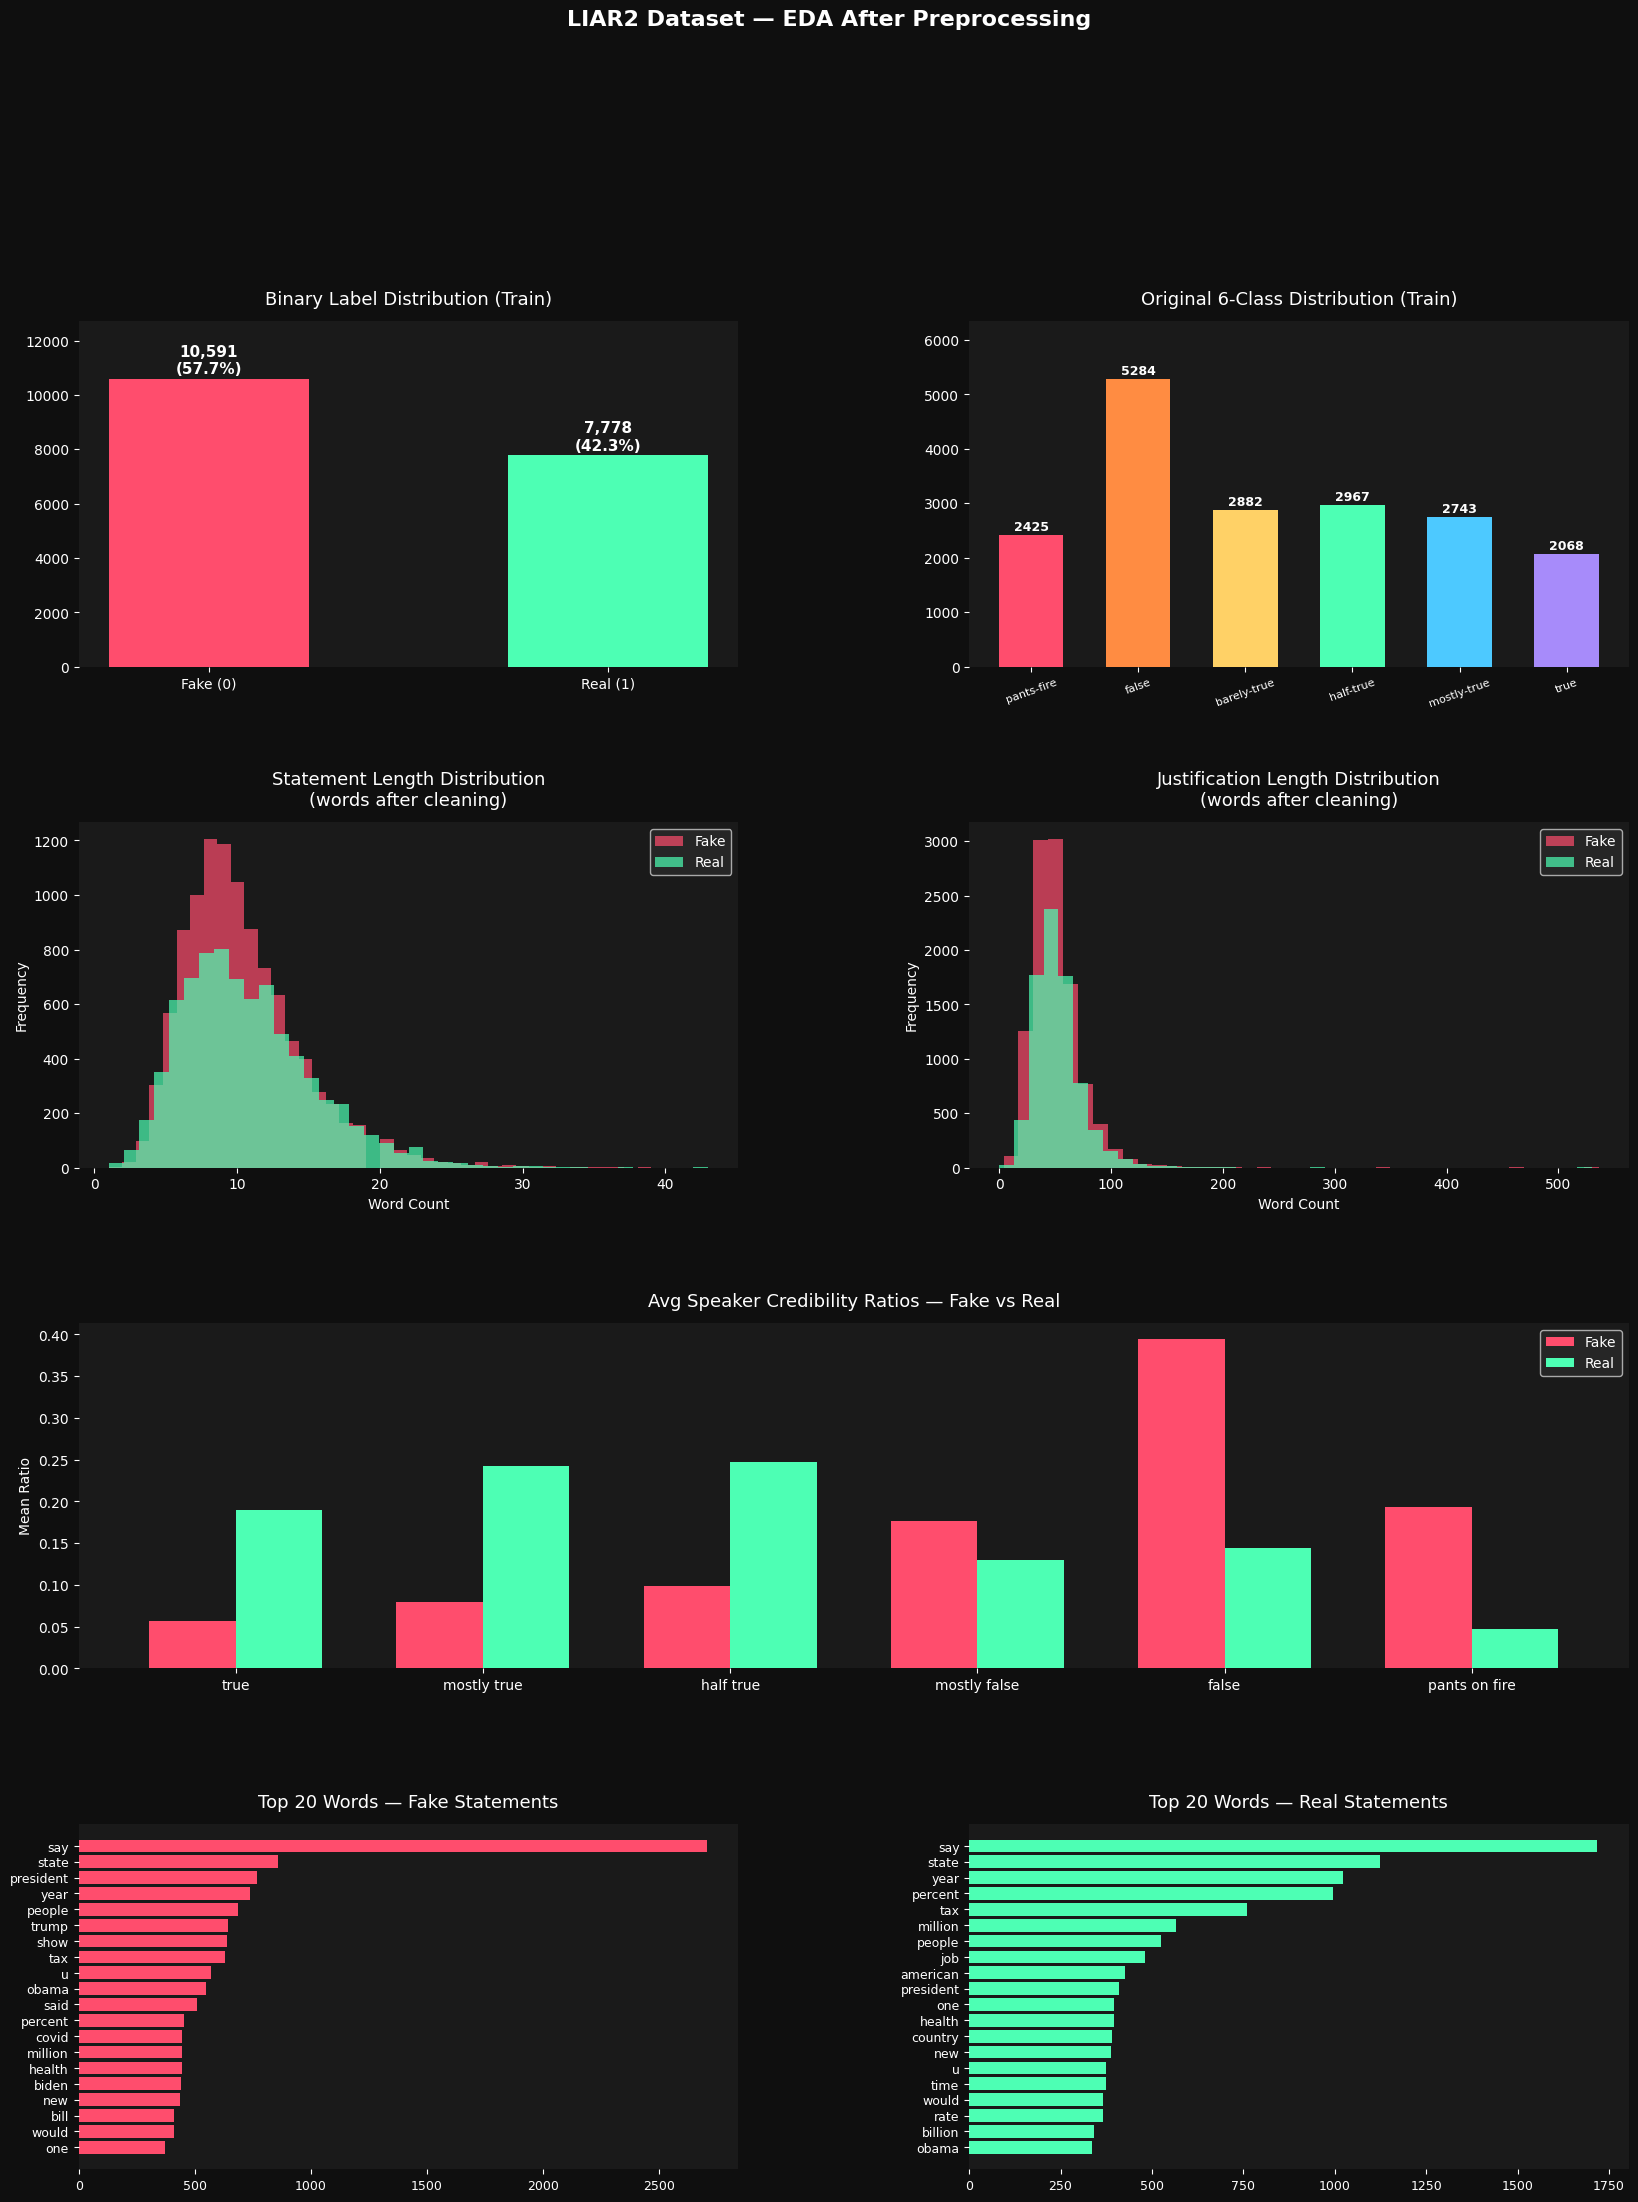

In [10]:

# EDA 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import numpy as np

plt.style.use('dark_background')
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0f0f0f')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

colors_binary = ['#ff4d6d', '#4dffb4']
colors_6 = ['#ff4d6d','#ff8c42','#ffd166','#4dffb4','#4dc9ff','#a78bfa']

# ── Plot 1: Binary Label Distribution ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
binary_counts = pd.Series(y_train).value_counts().sort_index()
bars = ax1.bar(['Fake (0)', 'Real (1)'], binary_counts.values,
               color=colors_binary, width=0.5, edgecolor='none')
for bar, val in zip(bars, binary_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'{val:,}\n({val/len(y_train)*100:.1f}%)',
             ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')
ax1.set_title('Binary Label Distribution (Train)', color='white', fontsize=13, pad=12)
ax1.set_facecolor('#1a1a1a')
ax1.tick_params(colors='white')
ax1.spines[:].set_visible(False)
ax1.set_ylim(0, binary_counts.max() * 1.2)

# ── Plot 2: Original 6-Class Distribution ──────────────────
ax2 = fig.add_subplot(gs[0, 1])
label_names = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
multi_counts = df_train['label'].value_counts().sort_index()
bars2 = ax2.bar(label_names, multi_counts.values,
                color=colors_6, width=0.6, edgecolor='none')
for bar, val in zip(bars2, multi_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax2.set_title('Original 6-Class Distribution (Train)', color='white', fontsize=13, pad=12)
ax2.set_facecolor('#1a1a1a')
ax2.tick_params(colors='white', axis='y')
ax2.tick_params(axis='x', colors='white', labelsize=8, rotation=20)
ax2.spines[:].set_visible(False)
ax2.set_ylim(0, multi_counts.max() * 1.2)

# ── Plot 3: Statement Length Distribution ──────────────────
ax3 = fig.add_subplot(gs[1, 0])
df_train['stmt_len'] = df_train['clean_statement'].apply(lambda x: len(x.split()))
fake_lens = df_train[y_train == 0]['stmt_len']
real_lens = df_train[y_train == 1]['stmt_len']
ax3.hist(fake_lens, bins=40, color='#ff4d6d', alpha=0.7, label='Fake', edgecolor='none')
ax3.hist(real_lens, bins=40, color='#4dffb4', alpha=0.7, label='Real', edgecolor='none')
ax3.set_title('Statement Length Distribution\n(words after cleaning)', color='white', fontsize=13, pad=12)
ax3.set_xlabel('Word Count', color='white')
ax3.set_ylabel('Frequency', color='white')
ax3.legend(facecolor='#2a2a2a', labelcolor='white')
ax3.set_facecolor('#1a1a1a')
ax3.tick_params(colors='white')
ax3.spines[:].set_visible(False)

# ── Plot 4: Justification Length Distribution ───────────────
ax4 = fig.add_subplot(gs[1, 1])
df_train['just_len'] = df_train['clean_justification'].apply(lambda x: len(x.split()))
fake_just = df_train[y_train == 0]['just_len']
real_just = df_train[y_train == 1]['just_len']
ax4.hist(fake_just, bins=40, color='#ff4d6d', alpha=0.7, label='Fake', edgecolor='none')
ax4.hist(real_just, bins=40, color='#4dffb4', alpha=0.7, label='Real', edgecolor='none')
ax4.set_title('Justification Length Distribution\n(words after cleaning)', color='white', fontsize=13, pad=12)
ax4.set_xlabel('Word Count', color='white')
ax4.set_ylabel('Frequency', color='white')
ax4.legend(facecolor='#2a2a2a', labelcolor='white')
ax4.set_facecolor('#1a1a1a')
ax4.tick_params(colors='white')
ax4.spines[:].set_visible(False)

# ── Plot 5: Speaker Credibility Ratios (Fake vs Real) ───────
ax5 = fig.add_subplot(gs[2, :])
ratio_cols = ['true_ratio', 'mostly_true_ratio', 'half_true_ratio',
              'mostly_false_ratio', 'false_ratio', 'pants_on_fire_ratio']
fake_means = df_train[ratio_cols][y_train == 0].mean()
real_means = df_train[ratio_cols][y_train == 1].mean()
x = np.arange(len(ratio_cols))
width = 0.35
bars_f = ax5.bar(x - width/2, fake_means, width, label='Fake',
                  color='#ff4d6d', edgecolor='none')
bars_r = ax5.bar(x + width/2, real_means, width, label='Real',
                  color='#4dffb4', edgecolor='none')
ax5.set_xticks(x)
ax5.set_xticklabels([r.replace('_ratio','').replace('_',' ') for r in ratio_cols],
                     color='white', fontsize=10)
ax5.set_title('Avg Speaker Credibility Ratios — Fake vs Real', color='white', fontsize=13, pad=12)
ax5.set_ylabel('Mean Ratio', color='white')
ax5.legend(facecolor='#2a2a2a', labelcolor='white')
ax5.set_facecolor('#1a1a1a')
ax5.tick_params(colors='white')
ax5.spines[:].set_visible(False)

# ── Plot 6: Top 20 Words in Fake Statements ─────────────────
ax6 = fig.add_subplot(gs[3, 0])
fake_text = ' '.join(df_train[y_train == 0]['clean_statement'])
fake_words = Counter(fake_text.split()).most_common(20)
words_f, counts_f = zip(*fake_words)
ax6.barh(list(reversed(words_f)), list(reversed(counts_f)),
          color='#ff4d6d', edgecolor='none')
ax6.set_title('Top 20 Words — Fake Statements', color='white', fontsize=13, pad=12)
ax6.set_facecolor('#1a1a1a')
ax6.tick_params(colors='white', labelsize=9)
ax6.spines[:].set_visible(False)

# ── Plot 7: Top 20 Words in Real Statements ─────────────────
ax7 = fig.add_subplot(gs[3, 1])
real_text = ' '.join(df_train[y_train == 1]['clean_statement'])
real_words = Counter(real_text.split()).most_common(20)
words_r, counts_r = zip(*real_words)
ax7.barh(list(reversed(words_r)), list(reversed(counts_r)),
          color='#4dffb4', edgecolor='none')
ax7.set_title('Top 20 Words — Real Statements', color='white', fontsize=13, pad=12)
ax7.set_facecolor('#1a1a1a')
ax7.tick_params(colors='white', labelsize=9)
ax7.spines[:].set_visible(False)

plt.suptitle('LIAR2 Dataset — EDA After Preprocessing',
             color='white', fontsize=16, fontweight='bold', y=1.01)
plt.show()

In [11]:

# SVM BASELINE
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, roc_curve, auc)
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import time

# Train
print("Training SVM...")
start = time.time()

svm = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42, C=1.0)

# CalibratedClassifierCV wraps LinearSVC so we can get
# probability scores needed for the ROC curve later
svm_calibrated = CalibratedClassifierCV(svm, cv=3)
svm_calibrated.fit(X_train_final, y_train)

elapsed = time.time() - start
print(f"Training complete in {elapsed:.1f}s")

# Predictions
y_valid_pred = svm_calibrated.predict(X_valid_final)
y_valid_prob  = svm_calibrated.predict_proba(X_valid_final)[:, 1]

y_test_pred  = svm_calibrated.predict(X_test_final)
y_test_prob   = svm_calibrated.predict_proba(X_test_final)[:, 1]

#Classification Reports
print("\n" + "="*55)
print("VALIDATION RESULTS")
print("="*55)
print(classification_report(y_valid, y_valid_pred,
                             target_names=['Fake', 'Real']))

print("="*55)
print("TEST RESULTS")
print("="*55)
print(classification_report(y_test, y_test_pred,
                             target_names=['Fake', 'Real']))

# Store key scores for later comparison
svm_scores = {
    'val_f1'  : f1_score(y_valid, y_valid_pred, average='weighted'),
    'test_f1' : f1_score(y_test,  y_test_pred,  average='weighted'),
    'val_f1_macro'  : f1_score(y_valid, y_valid_pred, average='macro'),
    'test_f1_macro' : f1_score(y_test,  y_test_pred,  average='macro'),
}
print(f"\nWeighted F1 — Valid: {svm_scores['val_f1']:.4f} | Test: {svm_scores['test_f1']:.4f}")
print(f"Macro    F1 — Valid: {svm_scores['val_f1_macro']:.4f} | Test: {svm_scores['test_f1_macro']:.4f}")

Training SVM...
Training complete in 1.9s

VALIDATION RESULTS
              precision    recall  f1-score   support

        Fake       0.88      0.88      0.88      1325
        Real       0.83      0.84      0.84       972

    accuracy                           0.86      2297
   macro avg       0.86      0.86      0.86      2297
weighted avg       0.86      0.86      0.86      2297

TEST RESULTS
              precision    recall  f1-score   support

        Fake       0.88      0.89      0.89      1323
        Real       0.85      0.84      0.84       973

    accuracy                           0.87      2296
   macro avg       0.87      0.86      0.87      2296
weighted avg       0.87      0.87      0.87      2296


Weighted F1 — Valid: 0.8617 | Test: 0.8684
Macro    F1 — Valid: 0.8584 | Test: 0.8652


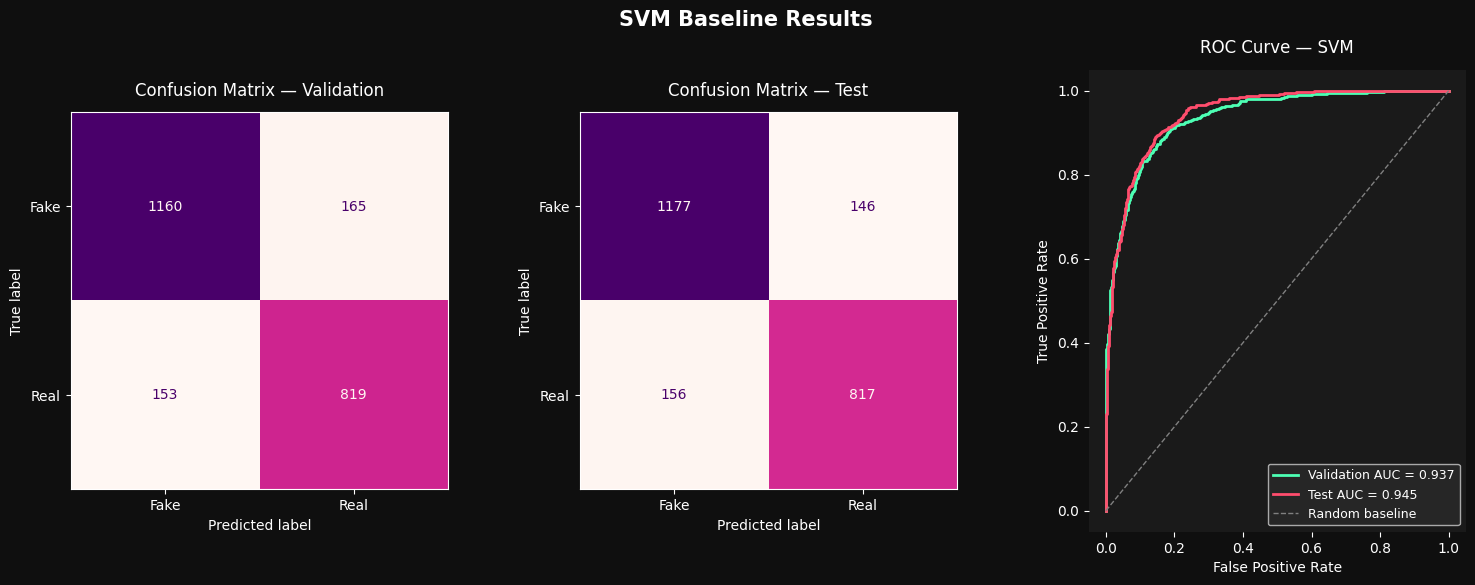

In [12]:
# Visuals
fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('#0f0f0f')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Confusion Matrix (Validation)
ax1 = fig.add_subplot(gs[0, 0])
cm_valid = confusion_matrix(y_valid, y_valid_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_valid,
                               display_labels=['Fake', 'Real'])
disp.plot(ax=ax1, colorbar=False, cmap='RdPu')
ax1.set_title('Confusion Matrix — Validation', color='white', fontsize=12, pad=12)
ax1.set_facecolor('#1a1a1a')
ax1.tick_params(colors='white')
ax1.xaxis.label.set_color('white')
ax1.yaxis.label.set_color('white')

# Confusion Matrix (Test) 
ax2 = fig.add_subplot(gs[0, 1])
cm_test = confusion_matrix(y_test, y_test_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                display_labels=['Fake', 'Real'])
disp2.plot(ax=ax2, colorbar=False, cmap='RdPu')
ax2.set_title('Confusion Matrix — Test', color='white', fontsize=12, pad=12)
ax2.set_facecolor('#1a1a1a')
ax2.tick_params(colors='white')
ax2.xaxis.label.set_color('white')
ax2.yaxis.label.set_color('white')

# ROC Curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1a1a')

fpr_v, tpr_v, _ = roc_curve(y_valid, y_valid_prob)
auc_v = auc(fpr_v, tpr_v)
fpr_t, tpr_t, _ = roc_curve(y_test,  y_test_prob)
auc_t = auc(fpr_t, tpr_t)

ax3.plot(fpr_v, tpr_v, color='#4dffb4', lw=2,
         label=f'Validation AUC = {auc_v:.3f}')
ax3.plot(fpr_t, tpr_t, color='#ff4d6d', lw=2,
         label=f'Test AUC = {auc_t:.3f}')
ax3.plot([0,1], [0,1], color='gray', lw=1,
         linestyle='--', label='Random baseline')
ax3.set_xlabel('False Positive Rate', color='white')
ax3.set_ylabel('True Positive Rate', color='white')
ax3.set_title('ROC Curve — SVM', color='white', fontsize=12, pad=12)
ax3.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9)
ax3.tick_params(colors='white')
ax3.spines[:].set_visible(False)

plt.suptitle('SVM Baseline Results', color='white',
             fontsize=15, fontweight='bold')

plt.show()


In [13]:

# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=300,        # 300 trees — good balance of performance vs speed
    class_weight='balanced', # handles 58/42 imbalance
    max_features='sqrt',     # each tree sees sqrt(50006) features — prevents correlation
    min_samples_leaf=2,      # prevents overfitting on noisy text features
    random_state=42,
    n_jobs=-1                # uses all CPU cores
)
rf.fit(X_train_final, y_train)

elapsed = time.time() - start
print(f"Training complete in {elapsed:.1f}s")

# Predictions
y_valid_pred_rf = rf.predict(X_valid_final)
y_valid_prob_rf = rf.predict_proba(X_valid_final)[:, 1]

y_test_pred_rf  = rf.predict(X_test_final)
y_test_prob_rf  = rf.predict_proba(X_test_final)[:, 1]

#Classification Reports
print("\n" + "="*55)
print("VALIDATION RESULTS")
print("="*55)
print(classification_report(y_valid, y_valid_pred_rf,
                             target_names=['Fake', 'Real']))

print("="*55)
print("TEST RESULTS")
print("="*55)
print(classification_report(y_test, y_test_pred_rf,
                             target_names=['Fake', 'Real']))

# Store scores
rf_scores = {
    'val_f1'        : f1_score(y_valid, y_valid_pred_rf, average='weighted'),
    'test_f1'       : f1_score(y_test,  y_test_pred_rf,  average='weighted'),
    'val_f1_macro'  : f1_score(y_valid, y_valid_pred_rf, average='macro'),
    'test_f1_macro' : f1_score(y_test,  y_test_pred_rf,  average='macro'),
}
print(f"\nWeighted F1 — Valid: {rf_scores['val_f1']:.4f} | Test: {rf_scores['test_f1']:.4f}")
print(f"Macro    F1 — Valid: {rf_scores['val_f1_macro']:.4f} | Test: {rf_scores['test_f1_macro']:.4f}")

Training Random Forest...
Training complete in 6.7s

VALIDATION RESULTS
              precision    recall  f1-score   support

        Fake       0.91      0.80      0.85      1325
        Real       0.77      0.90      0.83       972

    accuracy                           0.84      2297
   macro avg       0.84      0.85      0.84      2297
weighted avg       0.85      0.84      0.84      2297

TEST RESULTS
              precision    recall  f1-score   support

        Fake       0.92      0.82      0.87      1323
        Real       0.79      0.91      0.84       973

    accuracy                           0.86      2296
   macro avg       0.86      0.86      0.86      2296
weighted avg       0.87      0.86      0.86      2296


Weighted F1 — Valid: 0.8416 | Test: 0.8588
Macro    F1 — Valid: 0.8396 | Test: 0.8568


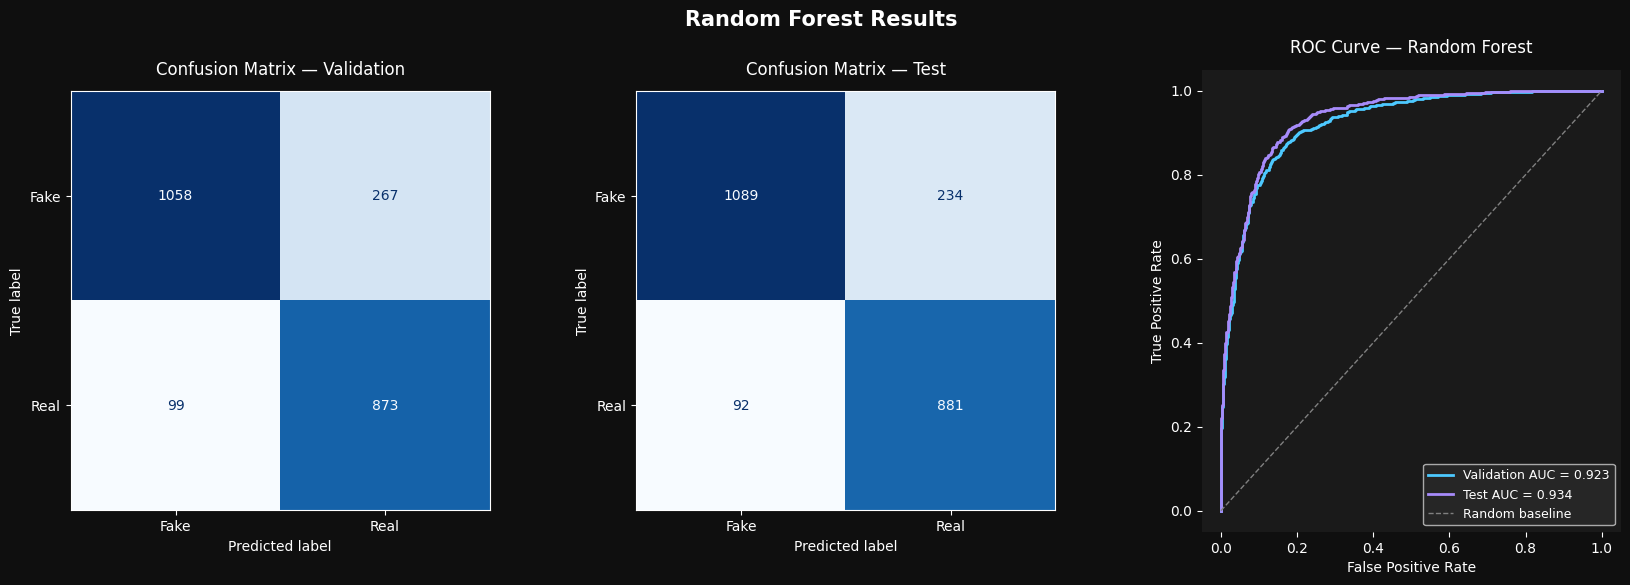

In [14]:
#Visuals
fig = plt.figure(figsize=(20, 6))
fig.patch.set_facecolor('#0f0f0f')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Confusion Matrix (Validation) 
ax1 = fig.add_subplot(gs[0, 0])
cm_valid_rf = confusion_matrix(y_valid, y_valid_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_valid_rf,
                               display_labels=['Fake', 'Real'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix — Validation', color='white', fontsize=12, pad=12)
ax1.set_facecolor('#1a1a1a')
ax1.tick_params(colors='white')
ax1.xaxis.label.set_color('white')
ax1.yaxis.label.set_color('white')

# Confusion Matrix (Test)
ax2 = fig.add_subplot(gs[0, 1])
cm_test_rf = confusion_matrix(y_test, y_test_pred_rf)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_test_rf,
                                display_labels=['Fake', 'Real'])
disp2.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix — Test', color='white', fontsize=12, pad=12)
ax2.set_facecolor('#1a1a1a')
ax2.tick_params(colors='white')
ax2.xaxis.label.set_color('white')
ax2.yaxis.label.set_color('white')

#  ROC Curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1a1a')

fpr_v, tpr_v, _ = roc_curve(y_valid, y_valid_prob_rf)
auc_v = auc(fpr_v, tpr_v)
fpr_t, tpr_t, _ = roc_curve(y_test,  y_test_prob_rf)
auc_t = auc(fpr_t, tpr_t)

ax3.plot(fpr_v, tpr_v, color='#4dc9ff', lw=2,
         label=f'Validation AUC = {auc_v:.3f}')
ax3.plot(fpr_t, tpr_t, color='#a78bfa', lw=2,
         label=f'Test AUC = {auc_t:.3f}')
ax3.plot([0,1], [0,1], color='gray', lw=1,
         linestyle='--', label='Random baseline')
ax3.set_xlabel('False Positive Rate', color='white')
ax3.set_ylabel('True Positive Rate', color='white')
ax3.set_title('ROC Curve — Random Forest', color='white', fontsize=12, pad=12)
ax3.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9)
ax3.tick_params(colors='white')
ax3.spines[:].set_visible(False)

plt.suptitle('Random Forest Results', color='white',
             fontsize=15, fontweight='bold')
plt.show()

In [29]:
# ============================================================
# BLOCK 1 — Imports (no gensim)
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
from collections import Counter
from sklearn.metrics import (classification_report, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(6)

print("All imports successful")
print("Device: CPU")

All imports successful
Device: CPU


In [30]:
# ============================================================
# BLOCK 2 — Tokenize Text for Word2Vec Training
# ============================================================
# Word2Vec needs list of token lists — one list per document
# We use combined_text which is already cleaned from earlier

def tokenize(text):
    return text.split()

train_sentences = df_train['combined_text'].apply(tokenize).tolist()
valid_sentences = df_valid['combined_text'].apply(tokenize).tolist()
test_sentences  = df_test['combined_text'].apply(tokenize).tolist()

# Word2Vec trains on ALL sentences for richer vocabulary
all_sentences = train_sentences + valid_sentences + test_sentences

print(f"Total sentences for W2V training: {len(all_sentences):,}")
print(f"Sample tokenized sentence: {train_sentences[0][:10]}")

Total sentences for W2V training: 22,962
Sample tokenized sentence: ['percent', 'american', 'support', 'universal', 'background', 'check', 'gun', 'purchase', 'universal', 'term']


In [32]:
# ============================================================
# BLOCK 3 — Build Vocabulary from Training Data
# (replaces Word2Vec training entirely)
# ============================================================
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
MIN_FREQ  = 2        # ignore words appearing less than 2 times

# Count word frequencies in training set only
word_counts = Counter()
for tokens in train_sentences:
    word_counts.update(tokens)

# Build word → index mapping
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        word2idx[word] = len(word2idx)

VOCAB_SIZE = len(word2idx)
EMBED_DIM  = 128
PAD_IDX    = 0
UNK_IDX    = 1

print(f"Vocabulary size : {VOCAB_SIZE:,}")
print(f"Words dropped   : {sum(1 for c in word_counts.values() if c < MIN_FREQ):,}")

Vocabulary size : 21,559
Words dropped   : 12,427


In [33]:
# ============================================================
# BLOCK 4 — Encode + Pad Sequences (unchanged)
# ============================================================
MAX_SEQ_LEN = 128

def encode_and_pad(sentences, word2idx, max_len):
    encoded = []
    for tokens in sentences:
        indices  = [word2idx.get(t, UNK_IDX) for t in tokens]
        indices  = indices[:max_len]
        indices += [PAD_IDX] * (max_len - len(indices))
        encoded.append(indices)
    return np.array(encoded, dtype=np.int64)

X_train_seq = encode_and_pad(train_sentences, word2idx, MAX_SEQ_LEN)
X_valid_seq = encode_and_pad(valid_sentences, word2idx, MAX_SEQ_LEN)
X_test_seq  = encode_and_pad(test_sentences,  word2idx, MAX_SEQ_LEN)

print(f"Train sequences shape : {X_train_seq.shape}")
print(f"Valid sequences shape : {X_valid_seq.shape}")
print(f"Test  sequences shape : {X_test_seq.shape}")

Train sequences shape : (18369, 128)
Valid sequences shape : (2297, 128)
Test  sequences shape : (2296, 128)


In [34]:
# ============================================================
# BLOCK 5 — PyTorch Dataset + DataLoader (unchanged)
# ============================================================
class FakeNewsDataset(Dataset):
    def __init__(self, sequences, meta_features, labels):
        self.sequences     = torch.tensor(sequences,     dtype=torch.long)
        self.meta_features = torch.tensor(meta_features, dtype=torch.float32)
        self.labels        = torch.tensor(labels,        dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.meta_features[idx], self.labels[idx]

BATCH_SIZE = 64

train_dataset = FakeNewsDataset(X_train_seq, X_train_meta, y_train)
valid_dataset = FakeNewsDataset(X_valid_seq, X_valid_meta, y_valid)
test_dataset  = FakeNewsDataset(X_test_seq,  X_test_meta,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 288
Valid batches : 36
Test  batches : 36


In [35]:
# ============================================================
# BLOCK 6 — LSTM Model Architecture
# (embedding layer now learns from scratch — no W2V needed)
# ============================================================
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, meta_dim,
                 pad_idx, dropout=0.3):
        super(LSTMClassifier, self).__init__()

        # Embedding learns from scratch during training
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=pad_idx)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        # hidden_dim * 2 (bidirectional) + meta_dim (credibility)
        self.fc = nn.Linear(hidden_dim * 2 + meta_dim, num_classes)

    def forward(self, sequences, meta):
        embedded = self.dropout(self.embedding(sequences))
        lstm_out, (hidden, _) = self.lstm(embedded)

        # Concat final forward + backward hidden states
        hidden_fwd = hidden[-2]
        hidden_bwd = hidden[-1]
        combined_hidden = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        combined_hidden = self.dropout(combined_hidden)

        # Concat with speaker credibility features
        combined = torch.cat([combined_hidden, meta], dim=1)
        return self.fc(combined)


HIDDEN_DIM  = 128
NUM_LAYERS  = 2
NUM_CLASSES = 2
META_DIM    = 6
DROPOUT     = 0.3

model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    meta_dim=META_DIM,
    pad_idx=PAD_IDX,
    dropout=DROPOUT
)

total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

LSTMClassifier(
  (embedding): Embedding(21559, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=262, out_features=2, bias=True)
)

Total trainable parameters: 3,419,534


In [37]:
# ============================================================
# BLOCK 7 — Training Setup (Fixed)
# ============================================================
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]],
    dtype=torch.float32
)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

EPOCHS           = 10
PATIENCE         = 3
best_val_loss    = float('inf')
patience_counter = 0
best_model_state = None

print("Training setup complete")
print(f"Class weights — Fake: {class_weights[0]:.4f} | "
      f"Real: {class_weights[1]:.4f}")

Training setup complete
Class weights — Fake: 0.4234 | Real: 0.5766


In [38]:
# ============================================================
# BLOCK 8 — Training Loop (unchanged)
# ============================================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for sequences, meta, labels in loader:
        optimizer.zero_grad()
        outputs = model(sequences, meta)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for sequences, meta, labels in loader:
            outputs    = model(sequences, meta)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            probs       = torch.softmax(outputs, dim=1)[:, 1]
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.numpy())
    return (total_loss / len(loader), correct / total,
            np.array(all_preds), np.array(all_labels),
            np.array(all_probs))


history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

print(f"{'Epoch':<8}{'Train Loss':<14}{'Train Acc':<14}"
      f"{'Val Loss':<14}{'Val Acc':<14}{'LR'}")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_preds, val_labels, val_probs = eval_epoch(
        model, valid_loader, criterion)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - start
    print(f"{epoch:<8}{train_loss:<14.4f}{train_acc:<14.4f}"
          f"{val_loss:<14.4f}{val_acc:<14.4f}{current_lr:.6f}"
          f"  ({elapsed:.0f}s)")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v
                            in model.state_dict().items()}
        print(f"  ✓ Best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print("\nTraining complete.")

Epoch   Train Loss    Train Acc     Val Loss      Val Acc       LR
----------------------------------------------------------------------
1       0.5345        0.7397        0.4538        0.7801        0.001000  (68s)
  ✓ Best model saved (val_loss=0.4538)
2       0.4114        0.8076        0.4010        0.8158        0.001000  (86s)
  ✓ Best model saved (val_loss=0.4010)
3       0.3870        0.8140        0.4102        0.8058        0.001000  (127s)
4       0.3701        0.8273        0.4234        0.7949        0.001000  (143s)
5       0.3476        0.8440        0.3948        0.8280        0.001000  (79s)
  ✓ Best model saved (val_loss=0.3948)
6       0.3673        0.8295        0.4501        0.7941        0.001000  (69s)
7       0.3237        0.8613        0.4173        0.8228        0.001000  (79s)
8       0.2746        0.8810        0.3856        0.8337        0.001000  (78s)
  ✓ Best model saved (val_loss=0.3856)
9       0.2415        0.8972        0.3998        0.8341        

In [39]:
# ============================================================
# BLOCK 9 — Evaluation (unchanged)
# ============================================================
model.load_state_dict(best_model_state)

_, _, val_preds, val_labels, val_probs = eval_epoch(
    model, valid_loader, criterion)
_, _, test_preds, test_labels, test_probs = eval_epoch(
    model, test_loader, criterion)

print("="*55)
print("VALIDATION RESULTS")
print("="*55)
print(classification_report(val_labels, val_preds,
                             target_names=['Fake', 'Real']))
print("="*55)
print("TEST RESULTS")
print("="*55)
print(classification_report(test_labels, test_preds,
                             target_names=['Fake', 'Real']))

lstm_scores = {
    'val_f1'       : f1_score(val_labels,  val_preds,
                               average='weighted'),
    'test_f1'      : f1_score(test_labels, test_preds,
                               average='weighted'),
    'val_f1_macro' : f1_score(val_labels,  val_preds,
                               average='macro'),
    'test_f1_macro': f1_score(test_labels, test_preds,
                               average='macro'),
}
print(f"\nWeighted F1 — Valid: {lstm_scores['val_f1']:.4f} | "
      f"Test: {lstm_scores['test_f1']:.4f}")
print(f"Macro    F1 — Valid: {lstm_scores['val_f1_macro']:.4f} | "
      f"Test: {lstm_scores['test_f1_macro']:.4f}")

VALIDATION RESULTS
              precision    recall  f1-score   support

        Fake       0.85      0.86      0.86      1325
        Real       0.81      0.80      0.80       972

    accuracy                           0.83      2297
   macro avg       0.83      0.83      0.83      2297
weighted avg       0.83      0.83      0.83      2297

TEST RESULTS
              precision    recall  f1-score   support

        Fake       0.87      0.88      0.87      1323
        Real       0.83      0.81      0.82       973

    accuracy                           0.85      2296
   macro avg       0.85      0.85      0.85      2296
weighted avg       0.85      0.85      0.85      2296


Weighted F1 — Valid: 0.8336 | Test: 0.8521
Macro    F1 — Valid: 0.8295 | Test: 0.8483


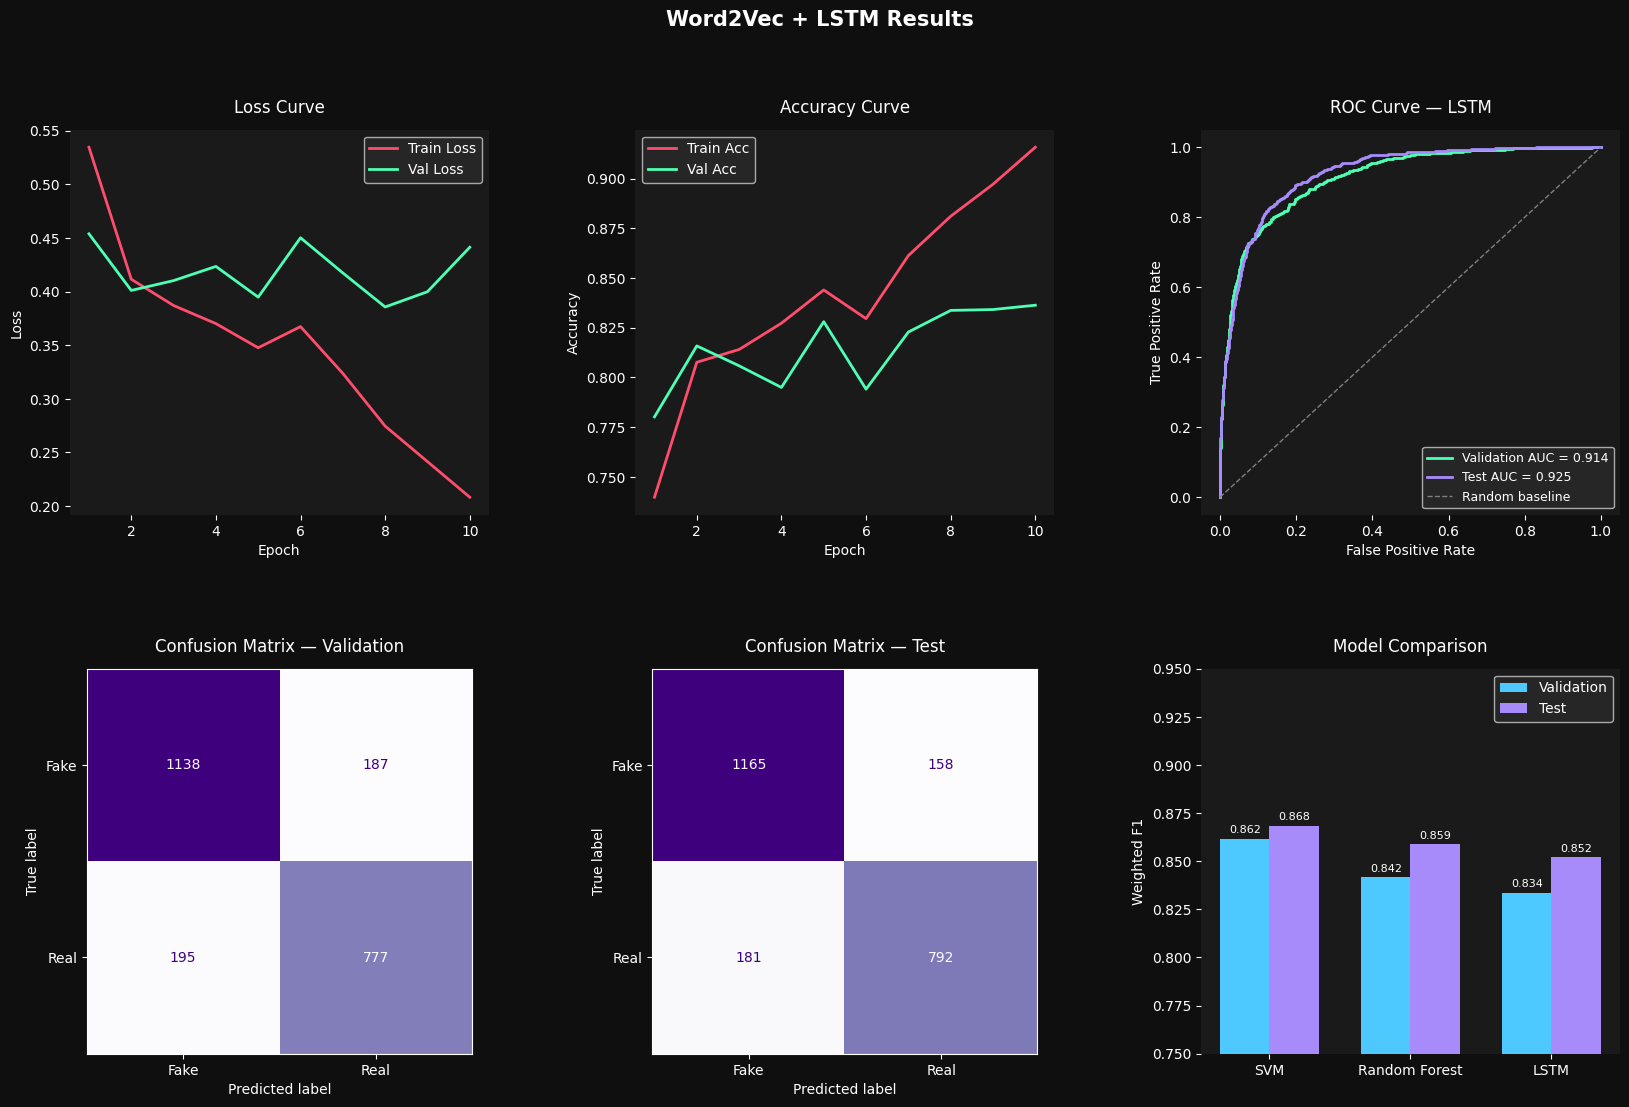

In [40]:
# ============================================================
# BLOCK 10 — Visuals (unchanged)
# ============================================================
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#0f0f0f')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Loss curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1a1a')
epochs_ran = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_ran, history['train_loss'],
         color='#ff4d6d', lw=2, label='Train Loss')
ax1.plot(epochs_ran, history['val_loss'],
         color='#4dffb4', lw=2, label='Val Loss')
ax1.set_title('Loss Curve', color='white', fontsize=12, pad=12)
ax1.set_xlabel('Epoch', color='white')
ax1.set_ylabel('Loss',  color='white')
ax1.legend(facecolor='#2a2a2a', labelcolor='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_visible(False)

# Accuracy curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1a1a')
ax2.plot(epochs_ran, history['train_acc'],
         color='#ff4d6d', lw=2, label='Train Acc')
ax2.plot(epochs_ran, history['val_acc'],
         color='#4dffb4', lw=2, label='Val Acc')
ax2.set_title('Accuracy Curve', color='white', fontsize=12, pad=12)
ax2.set_xlabel('Epoch', color='white')
ax2.set_ylabel('Accuracy', color='white')
ax2.legend(facecolor='#2a2a2a', labelcolor='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_visible(False)

# ROC curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1a1a')
fpr_v, tpr_v, _ = roc_curve(val_labels,  val_probs)
fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
auc_v = auc(fpr_v, tpr_v)
auc_t = auc(fpr_t, tpr_t)
ax3.plot(fpr_v, tpr_v, color='#4dffb4', lw=2,
         label=f'Validation AUC = {auc_v:.3f}')
ax3.plot(fpr_t, tpr_t, color='#a78bfa', lw=2,
         label=f'Test AUC = {auc_t:.3f}')
ax3.plot([0,1],[0,1], color='gray', lw=1,
         linestyle='--', label='Random baseline')
ax3.set_title('ROC Curve — LSTM', color='white', fontsize=12, pad=12)
ax3.set_xlabel('False Positive Rate', color='white')
ax3.set_ylabel('True Positive Rate',  color='white')
ax3.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9)
ax3.tick_params(colors='white')
ax3.spines[:].set_visible(False)

# Confusion matrix — validation
ax4 = fig.add_subplot(gs[1, 0])
cm_val = confusion_matrix(val_labels, val_preds)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_val,
                                 display_labels=['Fake', 'Real'])
disp.plot(ax=ax4, colorbar=False, cmap='Purples')
ax4.set_title('Confusion Matrix — Validation',
              color='white', fontsize=12, pad=12)
ax4.set_facecolor('#1a1a1a')
ax4.tick_params(colors='white')
ax4.xaxis.label.set_color('white')
ax4.yaxis.label.set_color('white')

# Confusion matrix — test
ax5 = fig.add_subplot(gs[1, 1])
cm_test = confusion_matrix(test_labels, test_preds)
disp2   = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                  display_labels=['Fake', 'Real'])
disp2.plot(ax=ax5, colorbar=False, cmap='Purples')
ax5.set_title('Confusion Matrix — Test',
              color='white', fontsize=12, pad=12)
ax5.set_facecolor('#1a1a1a')
ax5.tick_params(colors='white')
ax5.xaxis.label.set_color('white')
ax5.yaxis.label.set_color('white')

# Model comparison bar chart
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#1a1a1a')
models  = ['SVM', 'Random Forest', 'LSTM']
val_f1s = [svm_scores['val_f1'],  rf_scores['val_f1'],
           lstm_scores['val_f1']]
tst_f1s = [svm_scores['test_f1'], rf_scores['test_f1'],
           lstm_scores['test_f1']]
x     = np.arange(len(models))
width = 0.35
ax6.bar(x - width/2, val_f1s, width, color='#4dc9ff',
        label='Validation', edgecolor='none')
ax6.bar(x + width/2, tst_f1s, width, color='#a78bfa',
        label='Test', edgecolor='none')
for i, (v, t) in enumerate(zip(val_f1s, tst_f1s)):
    ax6.text(i - width/2, v + 0.003, f'{v:.3f}',
             ha='center', fontsize=8, color='white')
    ax6.text(i + width/2, t + 0.003, f'{t:.3f}',
             ha='center', fontsize=8, color='white')
ax6.set_xticks(x)
ax6.set_xticklabels(models, color='white')
ax6.set_ylabel('Weighted F1', color='white')
ax6.set_title('Model Comparison', color='white', fontsize=12, pad=12)
ax6.set_ylim(0.75, 0.95)
ax6.legend(facecolor='#2a2a2a', labelcolor='white')
ax6.tick_params(colors='white')
ax6.spines[:].set_visible(False)

plt.suptitle('Word2Vec + LSTM Results', color='white',
             fontsize=15, fontweight='bold')
plt.show()

In [41]:
# ============================================================
# SAVE ALL MODELS
# ============================================================
import os
import pickle
import torch

# Create models folder
os.makedirs('models', exist_ok=True)

# ── Save SVM ─────────────────────────────────────────────────
with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_calibrated, f)
print("✓ SVM saved")

# ── Save Random Forest ───────────────────────────────────────
with open('models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("✓ Random Forest saved")

# ── Save LSTM ────────────────────────────────────────────────
torch.save({
    'model_state_dict' : best_model_state,
    'word2idx'         : word2idx,
    'vocab_size'       : VOCAB_SIZE,
    'embed_dim'        : EMBED_DIM,
    'hidden_dim'       : HIDDEN_DIM,
    'num_layers'       : NUM_LAYERS,
    'num_classes'      : NUM_CLASSES,
    'meta_dim'         : META_DIM,
    'pad_idx'          : PAD_IDX,
    'dropout'          : DROPOUT,
    'max_seq_len'      : MAX_SEQ_LEN,
}, 'models/lstm_model.pt')
print("✓ LSTM saved")

# ── Save TF-IDF vectorizer + Scaler ──────────────────────────
# These are needed for preprocessing new data later
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✓ TF-IDF vectorizer saved")

with open('models/robust_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ RobustScaler saved")

# ── Verify ───────────────────────────────────────────────────
print("\nFiles in models folder:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / (1024*1024)
    print(f"  {f:<35} {size:.2f} MB")

✓ SVM saved
✓ Random Forest saved
✓ LSTM saved
✓ TF-IDF vectorizer saved
✓ RobustScaler saved

Files in models folder:
  lstm_model.pt                       13.48 MB
  rf_model.pkl                        67.12 MB
  robust_scaler.pkl                   0.00 MB
  svm_model.pkl                       1.15 MB
  tfidf_vectorizer.pkl                1.97 MB
